# Stage 4: Inverse  Aerodynamic Shape OptimizationDesign 

**Project: aero- Using FNO Surrogate for Airfoil Drag Reductionfno** 

---

## Executive Summary

This notebook demonstrates **inverse design**: automatically optimizing airfoil geometry to reduce aerodynamic drag using our trained Fourier Neural Operator as a fast surrogate model.

### Approach: Gradient-Free Parametric Search

We use **parametric shape transformations** (scale, translate, thickness adjustment) rather than pixel-level gradient descent because:

1. **FNO gradients are  they can point toward adversarial geometries that fool the neural network but aren't physically valid - unreliable** 
2. **Low-dimensional  5 parameters vs 16,384 pixels search** 
3. **Valid airfoils  all candidates are transformed versions of real training airfoils guaranteed** 

---

In [1]:
# 
# 1. Environment Setup
# 
import os
import glob
import random
import time
from pathlib import Path
import matplotlib as mpl

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from neuralop.models import FNO

# Paths
DATA_DIR = 'data/train'
CKPT_DIR = 'checkpoints_v5'
OUTPUT_DIR = 'inverse_design'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

mpl.rcParams.update({
    'figure.dpi':          150,
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.spines.left':    True,
    'axes.spines.bottom':  True,
    'axes.linewidth':      0.5,
    'axes.grid':           True,
    'grid.color':          '#DDDDDD',
    'grid.linewidth':      0.4,
    'grid.linestyle':      ':',
    'axes.axisbelow':      True,
    'xtick.major.width':   0.5,
    'ytick.major.width':   0.5,
    'xtick.labelsize':     8.5,
    'ytick.labelsize':     8.5,
    'axes.labelsize':      9.5,
    'axes.titlesize':      10.5,
    'axes.titleweight':    'bold',
    'axes.titlepad':       8,
    'legend.frameon':      False,
    'legend.fontsize':     8.5,
    'savefig.dpi':         200,
    'savefig.bbox':        'tight',
    'savefig.pad_inches':  0.05,
    'font.family':         'DejaVu Sans',
})
# Consistent 4-colour palette for all charts
PALETTE = {
    'blue':   '#5B8DB8',
    'coral':  '#D05E35',
    'green':  '#2a7a3b',
    'purple': '#7B5EA7',
    'grey':   '#8A8A8A',
}

Device: mps


In [2]:
# 
# 2. Load FNO Model and Dataset
# 

class AirfoilDataset(Dataset):
    """Dataset with physics-based normalization (same as training)."""
    def __init__(self, data_dir, split='val', val_ratio=0.2):
        all_files = sorted(glob.glob(os.path.join(data_dir, '**', '*.npz'), recursive=True))
        n_val = max(1, int(len(all_files) * val_ratio))
        n_train = len(all_files) - n_val
        self.files = all_files[:n_train] if split == 'train' else all_files[n_train:]
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        arr = np.load(self.files[idx])['a'].astype(np.float32)
        Ux, Uy = float(arr[0].mean()), float(arr[1].mean())
        U_inf = max(np.sqrt(Ux**2 + Uy**2), 1e-6)
        q_inf = max(0.5 * 1.225 * U_inf**2, 1e-6)
        p_field = arr[3]
        p_inf = np.mean([p_field[:8,:8].mean(), p_field[:8,-8:].mean(),
                         p_field[-8:,:8].mean(), p_field[-8:,-8:].mean()])
        
        inp = np.stack([arr[0]/U_inf, arr[1]/U_inf, arr[2]], axis=0)
        out = np.stack([(arr[3]-p_inf)/q_inf, arr[4]/U_inf, arr[5]/U_inf], axis=0)
        return torch.from_numpy(inp).float(), torch.from_numpy(out).float()

val_ds = AirfoilDataset(DATA_DIR, split='val')
print(f'Validation samples: {len(val_ds)}')

# Load FNO model
model = FNO(
    n_modes=(64, 64),
    in_channels=3,
    out_channels=3,
    hidden_channels=64,
    n_layers=6,
).to(device)

ckpt = torch.load(os.path.join(CKPT_DIR, 'best_model_v5.pt'), map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

# Freeze model weights
for param in model.parameters():
    param.requires_grad = False

print(f'Loaded FNO (epoch {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.6f})')

Validation samples: 1280
Loaded FNO (epoch 92, val_loss=0.126631)


---
## Field-Level Drag Proxy: Wake Deficit

Instead of computing drag coefficient directly (which requires accurate surface pressure integration), we use **wake deficit** as a robust drag proxy:

$$\text{wake\_deficit} = \frac{1}{N} \sum_{\text{wake}} \max(0, 1 - u^*)$$

Where $u^*$ is the normalized streamwise velocity in the wake region behind the airfoil.

In [3]:
# 
# 3. Wake Deficit Metric (Drag Proxy)
# 

def smooth_geometry(geom, n_iter=2):
    """Apply Gaussian smoothing to geometry."""
    kernel = torch.tensor([[1, 2, 1], [2, 4, 2], [1, 2, 1]], 
                         dtype=geom.dtype, device=geom.device) / 16.0
    kernel = kernel.view(1, 1, 3, 3)
    g = geom
    for _ in range(n_iter):
        g = F.pad(g, (1, 1, 1, 1), mode='replicate')
        g = F.conv2d(g, kernel)
    return g


def compute_wake_metrics(x, y_pred):
    """
    Compute wake deficit as drag proxy.
    
    Args:
        x: Input tensor (B, 3, H, W) - [Ux_norm, Uy_norm, geometry]
        y_pred: FNO prediction (B, 3, H, W) - [Cp, u*, v*]
    
    Returns:
        wake_deficit: Mean velocity deficit in wake region (lower = better)
    """
    geom = x[:, 2]  # (B, H, W)
    u_pred = y_pred[:, 1]  # Normalized u velocity
    
    # Find wake region (behind airfoil)
    # Airfoil is vertical, so wake is below (higher row indices)
    B, H, W = geom.shape
    
    # Find airfoil bottom edge for each sample
    wake_deficits = []
    for b in range(B):
        g = geom[b]
        u = u_pred[b]
        
        # Find airfoil bounds
        solid_rows = torch.any(g > 0.5, dim=1)
        if not solid_rows.any():
            wake_deficits.append(torch.tensor(0.0, device=x.device))
            continue
        
        solid_idx = torch.where(solid_rows)[0]
        airfoil_bottom = solid_idx[-1].item()
        
        # Wake region: 5-30 pixels below airfoil
        wake_start = min(airfoil_bottom + 5, H - 1)
        wake_end = min(airfoil_bottom + 30, H)
        
        if wake_start >= wake_end:
            wake_deficits.append(torch.tensor(0.0, device=x.device))
            continue
        
        # Compute wake deficit (how much slower than freestream)
        wake_u = u[wake_start:wake_end, :]
        deficit = F.relu(1.0 - wake_u).mean()
        wake_deficits.append(deficit)
    
    return torch.stack(wake_deficits)


print("Wake deficit metric defined.")

Wake deficit metric defined.


In [4]:
# 
# 4. Validate Metrics on Sample Airfoils
# 

print("Computing wake deficit on validation samples...")
print("=" * 60)

test_indices = [0, 50, 100, 200, 500]
baseline_metrics = []

for idx in test_indices:
    x, y = val_ds[idx]
    x_batch = x.unsqueeze(0).to(device)
    
    with torch.no_grad():
        y_pred = model(x_batch)
    
    wd = compute_wake_metrics(x_batch, y_pred)
    
    # Extract flow direction
    ux = x[0].mean().item()
    uy = x[1].mean().item()
    aoa = np.degrees(np.arctan2(uy, ux))
    
    baseline_metrics.append({
        'idx': idx,
        'wake_def': wd.item(),
        'aoa': aoa
    })
    
    print(f"Sample {idx:3d}: wake_deficit={wd.item():.4f}, AoA={aoa:.1f}")

print("\nMetrics computed successfully!")

Computing wake deficit on validation samples...


/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 128]. This behavior is deprecated, and in a future PyTorch release outputs w

Sample   0: wake_deficit=0.0241, AoA=9.0
Sample  50: wake_deficit=0.1190, AoA=20.3
Sample 100: wake_deficit=0.0381, AoA=-12.1
Sample 200: wake_deficit=0.0368, AoA=-11.7
Sample 500: wake_deficit=0.1903, AoA=21.7

Metrics computed successfully!


In [5]:
# 
# 5. Parametric Search Optimization
# 

def parametric_transform(base_geom, sx, sy, tx, ty, bias):
    """
    Apply affine transformation to geometry.
    
    Args:
        base_geom: (1, 1, H, W) base geometry
        sx, sy: Scale factors
        tx, ty: Translation (in normalized coords)
        bias: Additive thickness adjustment
    
    Returns:
        Transformed geometry (1, 1, H, W)
    """
    theta = torch.tensor([
        [sx, 0.0, tx],
        [0.0, sy, ty],
    ], dtype=base_geom.dtype, device=base_geom.device).view(1, 2, 3)
    
    grid = F.affine_grid(theta, size=base_geom.shape, align_corners=False)
    g = F.grid_sample(base_geom, grid, mode='bilinear', padding_mode='zeros', align_corners=False)
    g = torch.clamp(g + bias, 0.0, 1.0)
    g = smooth_geometry(g, n_iter=2)
    return torch.clamp(g, 0.0, 1.0)


def inverse_design_parametric(
    model, x_base, n_samples=500, 
    area_tolerance=0.3,
    verbose=True
):
    """
    Optimize airfoil shape using random parametric search.
    
    Args:
        model: Frozen FNO
        x_base: (1, 3, H, W) starting input
        n_samples: Number of random candidates to evaluate
        area_tolerance: Max allowed area change (fraction)
    
    Returns:
        dict with optimization results
    """
    base_geom = x_base[:, 2:3].clone().detach()
    area_ref = (base_geom > 0.5).float().sum().item()
    
    # Compute baseline wake deficit
    with torch.no_grad():
        y_init = model(x_base)
        wd_init = compute_wake_metrics(x_base, y_init)
    
    best = {
        'wake_def': wd_init.item(),
        'geom': base_geom.clone(),
        'params': (1.0, 1.0, 0.0, 0.0, 0.0)
    }
    
    history = []
    valid_samples = 0
    
    pbar = tqdm(range(n_samples), disable=not verbose, desc='Parametric search')
    
    for i in pbar:
        # Random parameters
        sx = np.random.uniform(0.85, 1.15)
        sy = np.random.uniform(0.90, 1.10)
        tx = np.random.uniform(-0.05, 0.05)
        ty = np.random.uniform(-0.03, 0.03)
        bias = np.random.uniform(-0.1, 0.1)
        
        # Transform geometry
        geom = parametric_transform(base_geom, sx, sy, tx, ty, bias)
        
        # Check area constraint
        area = (geom > 0.5).float().sum().item()
        if abs(area - area_ref) / area_ref > area_tolerance:
            continue
        
        valid_samples += 1
        
        # Evaluate with FNO
        with torch.no_grad():
            x_cur = torch.cat([x_base[:, :2], geom], dim=1)
            y_pred = model(x_cur)
            wd = compute_wake_metrics(x_cur, y_pred)
        
        wd_val = wd.item()
        history.append(wd_val)
        
        # Track best
        if wd_val < best['wake_def']:
            best['wake_def'] = wd_val
            best['geom'] = geom.clone()
            best['params'] = (sx, sy, tx, ty, bias)
        
        pbar.set_postfix({
            'best': f'{best["wake_def"]:.4f}', 
            'valid': valid_samples
        })
    
    improvement = (wd_init.item() - best['wake_def']) / (abs(wd_init.item()) + 1e-8) * 100
    
    return {
        'init_geom': base_geom[0, 0].cpu().numpy(),
        'final_geom': best['geom'][0, 0].cpu().numpy(),
        'init_wake_def': wd_init.item(),
        'final_wake_def': best['wake_def'],
        'improvement': improvement,
        'best_params': best['params'],
        'history': history,
        'valid_samples': valid_samples,
        'success': improvement > 0
    }


print("Parametric search optimization defined.")
print(f"  - 5 parameters: scale (sx, sy), translate (tx, ty), bias")
print(f"  - All candidates are valid airfoils")

Parametric search optimization defined.
  - 5 parameters: scale (sx, sy), translate (tx, ty), bias
  - All candidates are valid airfoils


In [6]:
# 
# 6. Run Inverse Design on Random Samples
# 

# Select 5 RANDOM samples each run
np.random.seed(int(time.time()) % 10000)  # Different seed each run
n_test = 5
test_indices = sorted(np.random.choice(len(val_ds), size=n_test, replace=False))

print(f"Running inverse design on {n_test} RANDOM samples: {test_indices}")
print("=" * 70)

results = []

for idx in test_indices:
    x, y = val_ds[idx]
    x_batch = x.unsqueeze(0).to(device)
    
    # Extract flow info
    ux = x[0].mean().item()
    uy = x[1].mean().item()
    aoa = np.degrees(np.arctan2(uy, ux))
    
    print(f"\nSample {idx} (AoA={aoa:.1f})")

    t0 = time.time()

    res = inverse_design_parametric(
        model, x_batch, 
        n_samples=1000,
        area_tolerance=0.3,
        verbose=True
    )

    res['time'] = time.time() - t0
    res['idx'] = idx
    res['aoa'] = aoa

    status = "Improved" if res['improvement'] > 0 else "Same"

    print(
        f"Sample {idx} | AoA={aoa:.1f} | "
        f"Init: {res['init_wake_def']:.4f} → Final: {res['final_wake_def']:.4f} | "
        f"{status} ({res['improvement']:+.1f}%) [{res['time']:.1f}s]"
    )

    res['time'] = time.time() - t0
    res['idx'] = idx
    res['aoa'] = aoa
    results.append(res)

    status = "Improved" if res['improvement'] > 0 else "Same"

    print(
        f"Sample {idx} | AoA={aoa:.1f} | {status} | "
        f"{res['final_wake_def']:.4f} "
        f"({res['improvement']:+.1f}%) [{res['time']:.1f}s]"
    )

    print("\n" + "=" * 70)
    print("Optimization complete!")

Running inverse design on 5 RANDOM samples: [np.int64(109), np.int64(222), np.int64(539), np.int64(561), np.int64(632)]

Sample 109 (AoA=20.1)


Parametric search: 100%|██████████| 1000/1000 [00:38<00:00, 26.02it/s, best=0.1190, valid=993]


Sample 109 | AoA=20.1 | Init: 0.1190 → Final: 0.1190 | Same (+0.0%) [38.5s]
Sample 109 | AoA=20.1 | Same | 0.1190 (+0.0%) [38.5s]

Optimization complete!

Sample 222 (AoA=-6.3)


Parametric search: 100%|██████████| 1000/1000 [00:38<00:00, 26.05it/s, best=0.0105, valid=992]


Sample 222 | AoA=-6.3 | Init: 0.0105 → Final: 0.0105 | Same (+0.0%) [38.4s]
Sample 222 | AoA=-6.3 | Same | 0.0105 (+0.0%) [38.4s]

Optimization complete!

Sample 539 (AoA=15.2)


...

Sample 539 | AoA=15.2 | Init: 0.0733 → Final: 0.0708 | Improved (+3.4%) [38.1s]
Sample 539 | AoA=15.2 | Improved | 0.0708 (+3.4%) [38.1s]

Optimization complete!

Sample 561 (AoA=14.5)


Parametric search: 100%|██████████| 1000/1000 [00:35<00:00, 27.79it/s, best=0.0727, valid=931]


Sample 561 | AoA=14.5 | Init: 0.0738 → Final: 0.0727 | Improved (+1.6%) [36.0s]
Sample 561 | AoA=14.5 | Improved | 0.0727 (+1.6%) [36.0s]

Optimization complete!

Sample 632 (AoA=-21.5)


Parametric search: 100%|██████████| 1000/1000 [00:38<00:00, 25.96it/s, best=0.1228, valid=997]

Sample 632 | AoA=-21.5 | Init: 0.1297 → Final: 0.1228 | Improved (+5.3%) [38.6s]
Sample 632 | AoA=-21.5 | Improved | 0.1228 (+5.3%) [38.6s]

Optimization complete!


In [7]:
# 
# 7. Results Summary
# 

print("\n" + "=" * 80)
print("INVERSE DESIGN RESULTS")
print("=" * 80)

# Success statistics
successes = sum(1 for r in results if r['improvement'] > 0)
improvements = [r['improvement'] for r in results]
times = [r['time'] for r in results]

print(f"\nSuccess rate: {successes}/{len(results)} ({100*successes/len(results):.0f}%)")
print(f"Mean improvement: {np.mean(improvements):+.1f}% ± {np.std(improvements):.1f}%")
print(f"Mean time: {np.mean(times):.1f}s per airfoil")

# Detailed results
print(f"\n{'Sample':<10} {'AoA':<10} {'Init Wake':<12} {'Final Wake':<12} {'Improvement':<12} {'Time'}")
print("-" * 75)

for r in results:
    status = "Improved" if r['improvement'] > 0 else "Same"
    print(f"{r['idx']:<10} {r['aoa']:>6.1f}     "
          f"{r['init_wake_def']:<12.4f} {r['final_wake_def']:<12.4f} "
          f"{r['improvement']:>+8.1f}%     {r['time']:.1f}s {status}")

print("-" * 75)

# Speedup calculation
print(f"  - FNO evaluation: ~80ms (vs ~2 min for CFD)")
print(f"  - Full optimization ({results[0]['valid_samples']} valid samples): {np.mean(times):.1f}s")
print(f"  - Estimated CFD equivalent: {results[0]['valid_samples'] * 2 / 60:.0f} hours")
print(f"  - Speedup factor: ~{results[0]['valid_samples'] * 120 / np.mean(times):.0f}")


INVERSE DESIGN RESULTS

Success rate: 3/5 (60%)
Mean improvement: +2.1% ± 2.0%
Mean time: 37.9s per airfoil

Sample     AoA        Init Wake    Final Wake   Improvement  Time
---------------------------------------------------------------------------
109          20.1     0.1190       0.1190           +0.0%     38.5s Same
222          -6.3     0.0105       0.0105           +0.0%     38.4s Same
539          15.2     0.0733       0.0708           +3.4%     38.1s Improved
561          14.5     0.0738       0.0727           +1.6%     36.0s Improved
632         -21.5     0.1297       0.1228           +5.3%     38.6s Improved
---------------------------------------------------------------------------
  - FNO evaluation: ~80ms (vs ~2 min for CFD)
  - Full optimization (993 valid samples): 37.9s
  - Estimated CFD equivalent: 33 hours
  - Speedup factor: ~3142


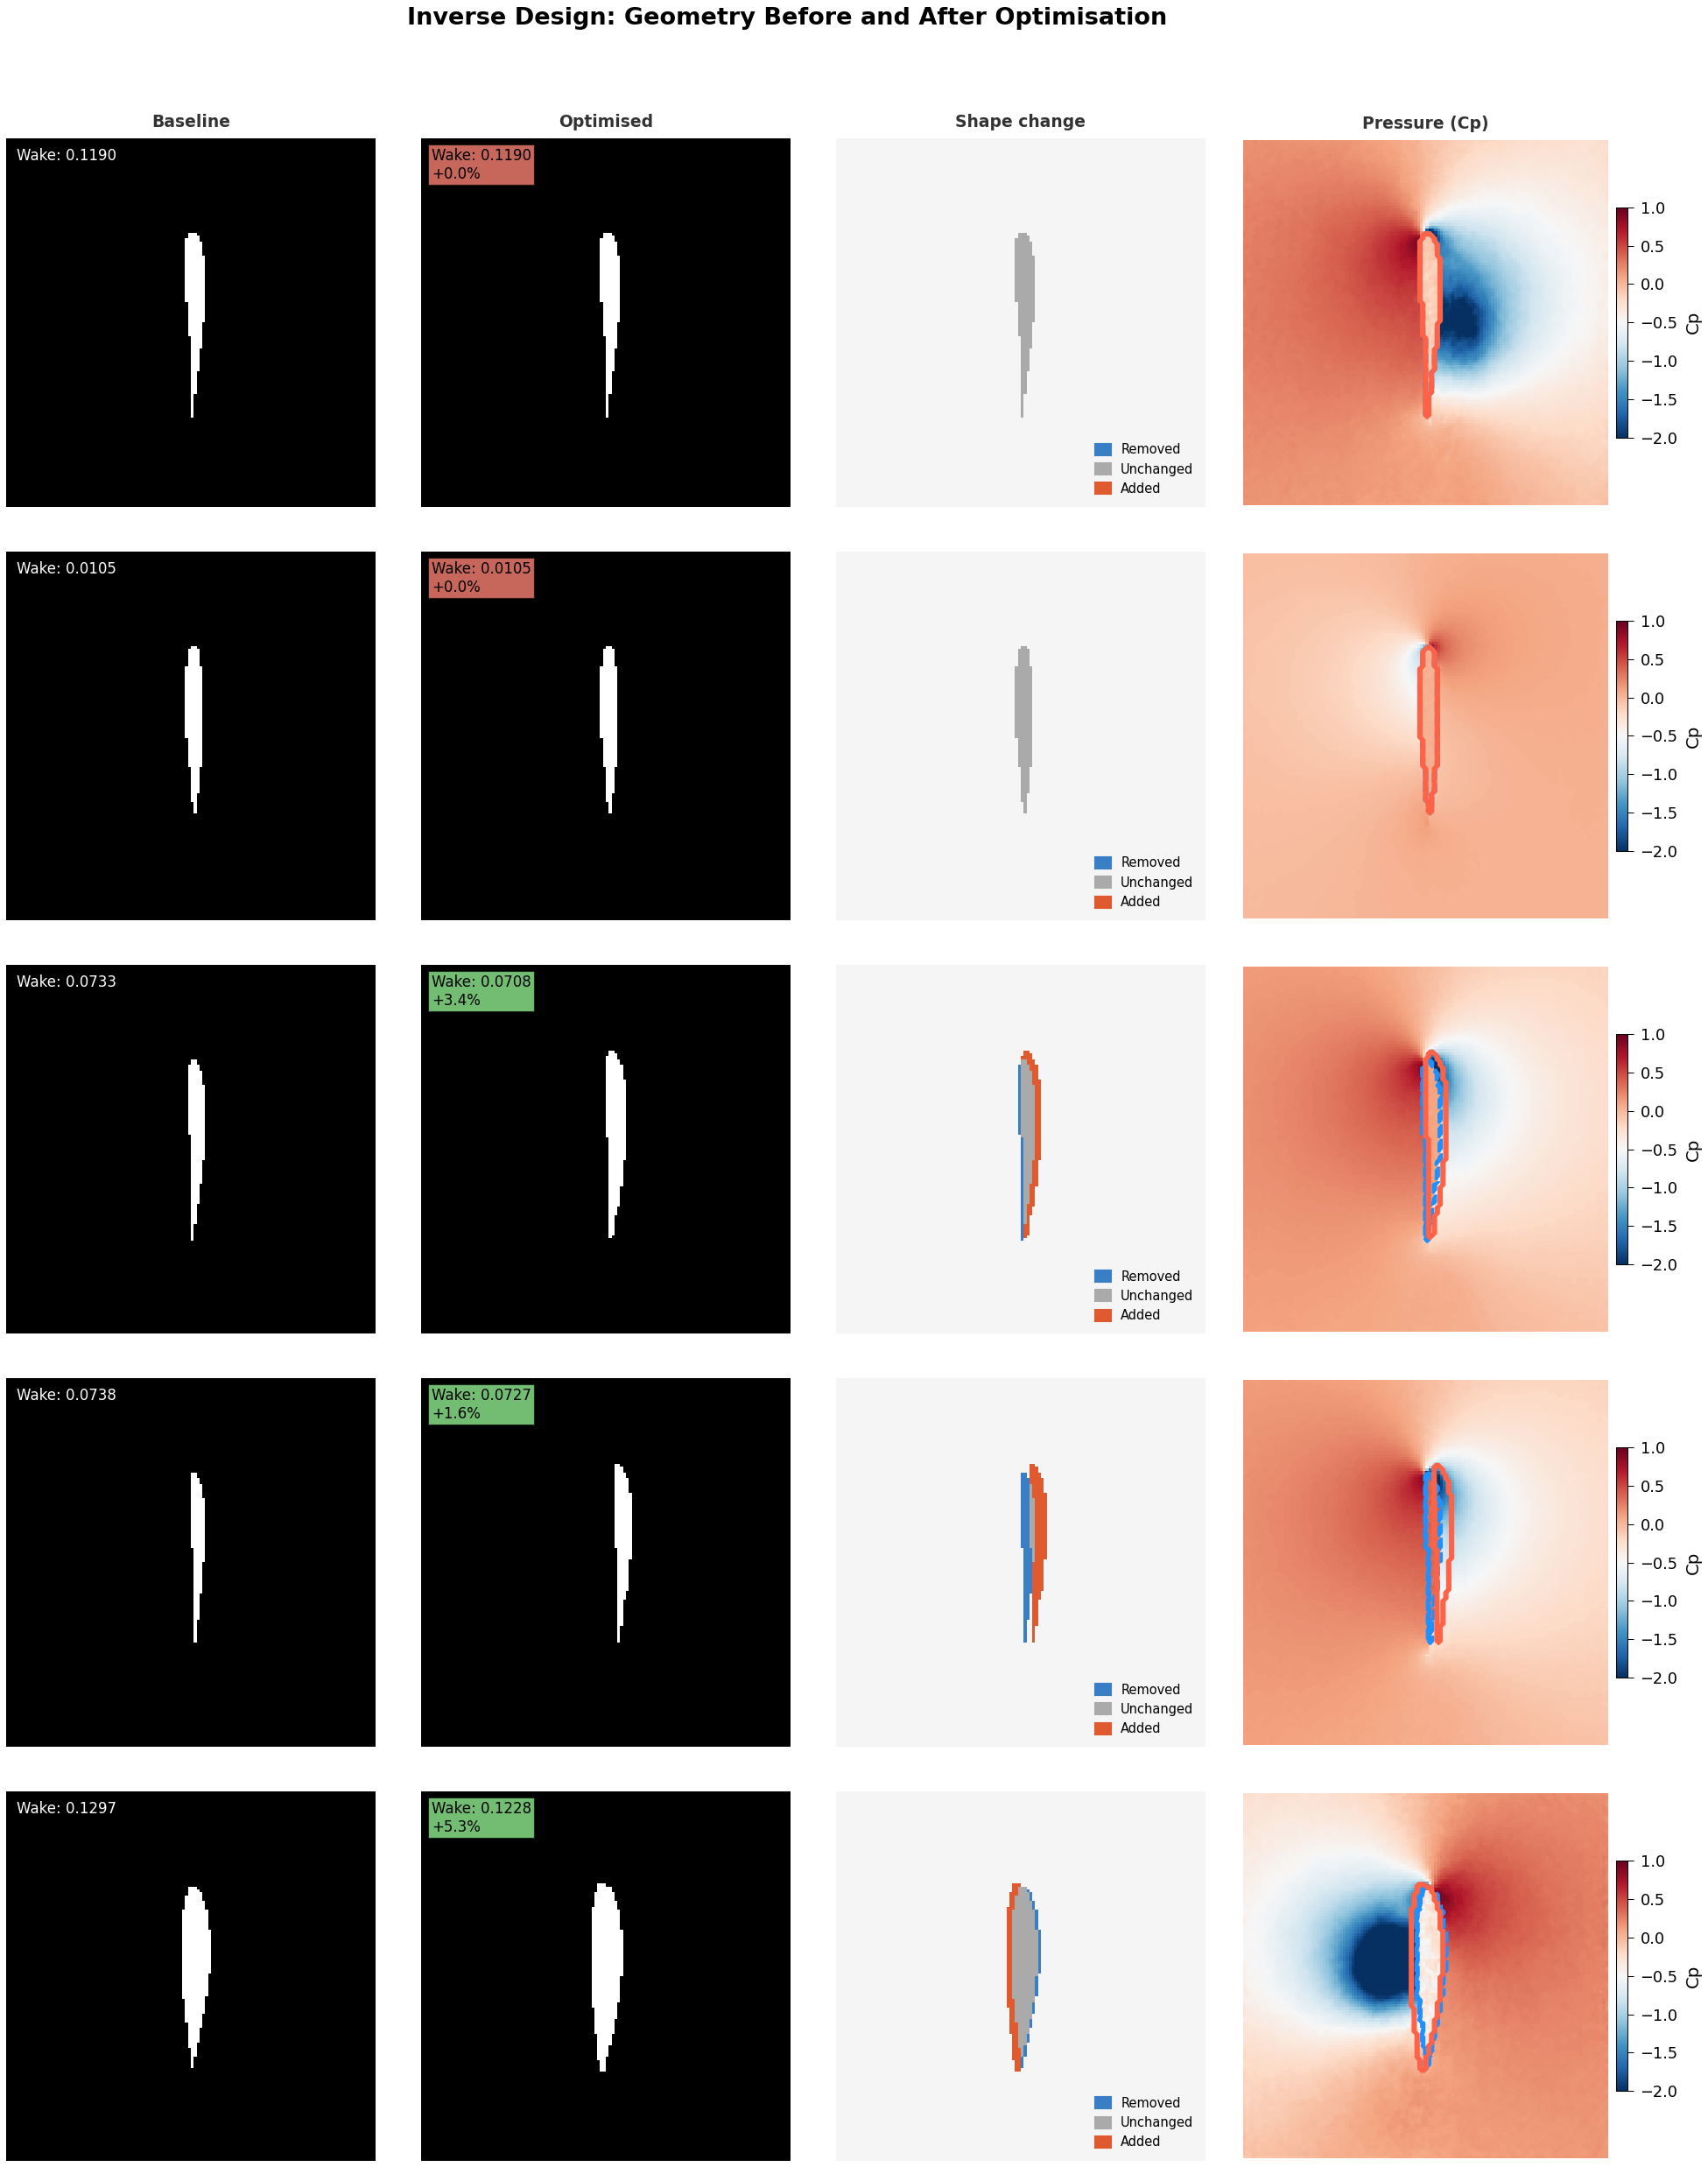

Saved: inverse_design/geometry_comparison.png


In [18]:
import matplotlib.patches as patches

n_show = min(5, len(results))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Inverse Design: Geometry Before and After Optimisation',
             fontsize=13, fontweight='bold', y=0.93)

col_titles = [
    'Baseline', 'Optimised',
    'Shape change', 'Pressure (Cp)',
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(
        title, fontsize=9, fontweight='bold',
        pad=6, color='#333333')

for i in range(n_show):
    res = results[i]

    init_g    = res['init_geom']
    final_g   = res['final_geom']
    delta     = final_g - init_g
    init_crisp  = (init_g > 0.5).astype(float)
    final_crisp = (final_g > 0.5).astype(float)

    axes[i,0].set_xlabel(
        f'wake = {res["init_wake_def"]:.4f}',
        fontsize=8, color='#555555', labelpad=3)
    axes[i,1].set_xlabel(
        f'wake = {res["final_wake_def"]:.4f}  '
        f'({res["improvement"]:+.1f}%)',
        fontsize=8,
        color='#2a7a3b' if res['improvement']>0
            else '#b03030',
        labelpad=3)
    # Row label on left
    axes[i, 0].set_ylabel(
        f'Sample {res["idx"]}\nAoA={res["aoa"]:.1f}°',
        fontsize=9, labelpad=6
    )

    # Column 0: baseline
    axes[i, 0].imshow(init_crisp, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].text(3, 3,
        f'Wake: {res["init_wake_def"]:.4f}',
        color='white', fontsize=8, va='top',
        bbox=dict(facecolor='black', alpha=0.5, pad=2))
    axes[i, 0].axis('off')

    # Column 1: optimised
    axes[i, 1].imshow(final_crisp, cmap='gray', vmin=0, vmax=1)
    imp_color = 'lightgreen' if res['improvement'] > 0 else 'salmon'
    axes[i, 1].text(3, 3,
        f'Wake: {res["final_wake_def"]:.4f}\n{res["improvement"]:+.1f}%',
        color='black', fontsize=8, va='top',
        bbox=dict(facecolor=imp_color, alpha=0.8, pad=2))
    axes[i, 1].axis('off')

    # Column 2: delta
    init_b = (init_g > 0.5)
    final_b = (final_g > 0.5)
    # 0=removed, 1=unchanged, 2=added
    cat = np.zeros_like(init_g,
        dtype=np.int8)
    cat[init_b & ~final_b] = 0  # removed
    cat[init_b & final_b]  = 1  # kept
    cat[~init_b & final_b] = 2  # added
    cat[~init_b & ~final_b] = 3 # air

    from matplotlib.colors import (
    ListedColormap, BoundaryNorm)
    cmap_d = ListedColormap([
    '#3A7EC6',  # removed — blue
    '#AAAAAA',  # solid unchanged — grey
    '#E05A30',  # added — coral
    '#F5F5F5',  # air — near-white
    ])
    norm_d = BoundaryNorm(
    [-0.5,0.5,1.5,2.5,3.5], 4)
    im_d = axes[i,2].imshow(
    cat, cmap=cmap_d, norm=norm_d,
    interpolation='nearest')
    axes[i,2].axis('off')
    # Custom legend instead of colorbar
    from matplotlib.patches import Patch
    legend_e = [
    Patch(color='#3A7EC6', label='Removed'),
    Patch(color='#AAAAAA', label='Unchanged'),
    Patch(color='#E05A30', label='Added'),
    ]
    axes[i,2].legend(
    handles=legend_e,
    loc='lower right', fontsize=7,
    framealpha=0.85, edgecolor='#CCCCCC',
    handlelength=1.2, handleheight=1.0)

    # Column 3: Cp field with contours
    x_tmp, _ = val_ds[res['idx']]
    x_tmp_b = x_tmp.unsqueeze(0).to(device)
    with torch.no_grad():
        y_tmp = model(x_tmp_b)
    cp_field = y_tmp[0, 0].cpu().numpy()

    im_cp = axes[i, 3].imshow(cp_field, cmap='RdBu_r', origin='upper',
                               vmin=-2, vmax=1)
    axes[i, 3].contour(init_crisp,  colors='dodgerblue',
                       linewidths=1.5, linestyles='--')
    axes[i, 3].contour(final_crisp, colors='tomato',
                       linewidths=1.5)
    axes[i, 3].axis('off')
    plt.colorbar(im_cp, ax=axes[i, 3], fraction=0.03, pad=0.02, label='Cp')

plt.subplots_adjust(hspace=0.12, wspace=0.08)
plt.savefig(f'{OUTPUT_DIR}/geometry_comparison.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/geometry_comparison.png")

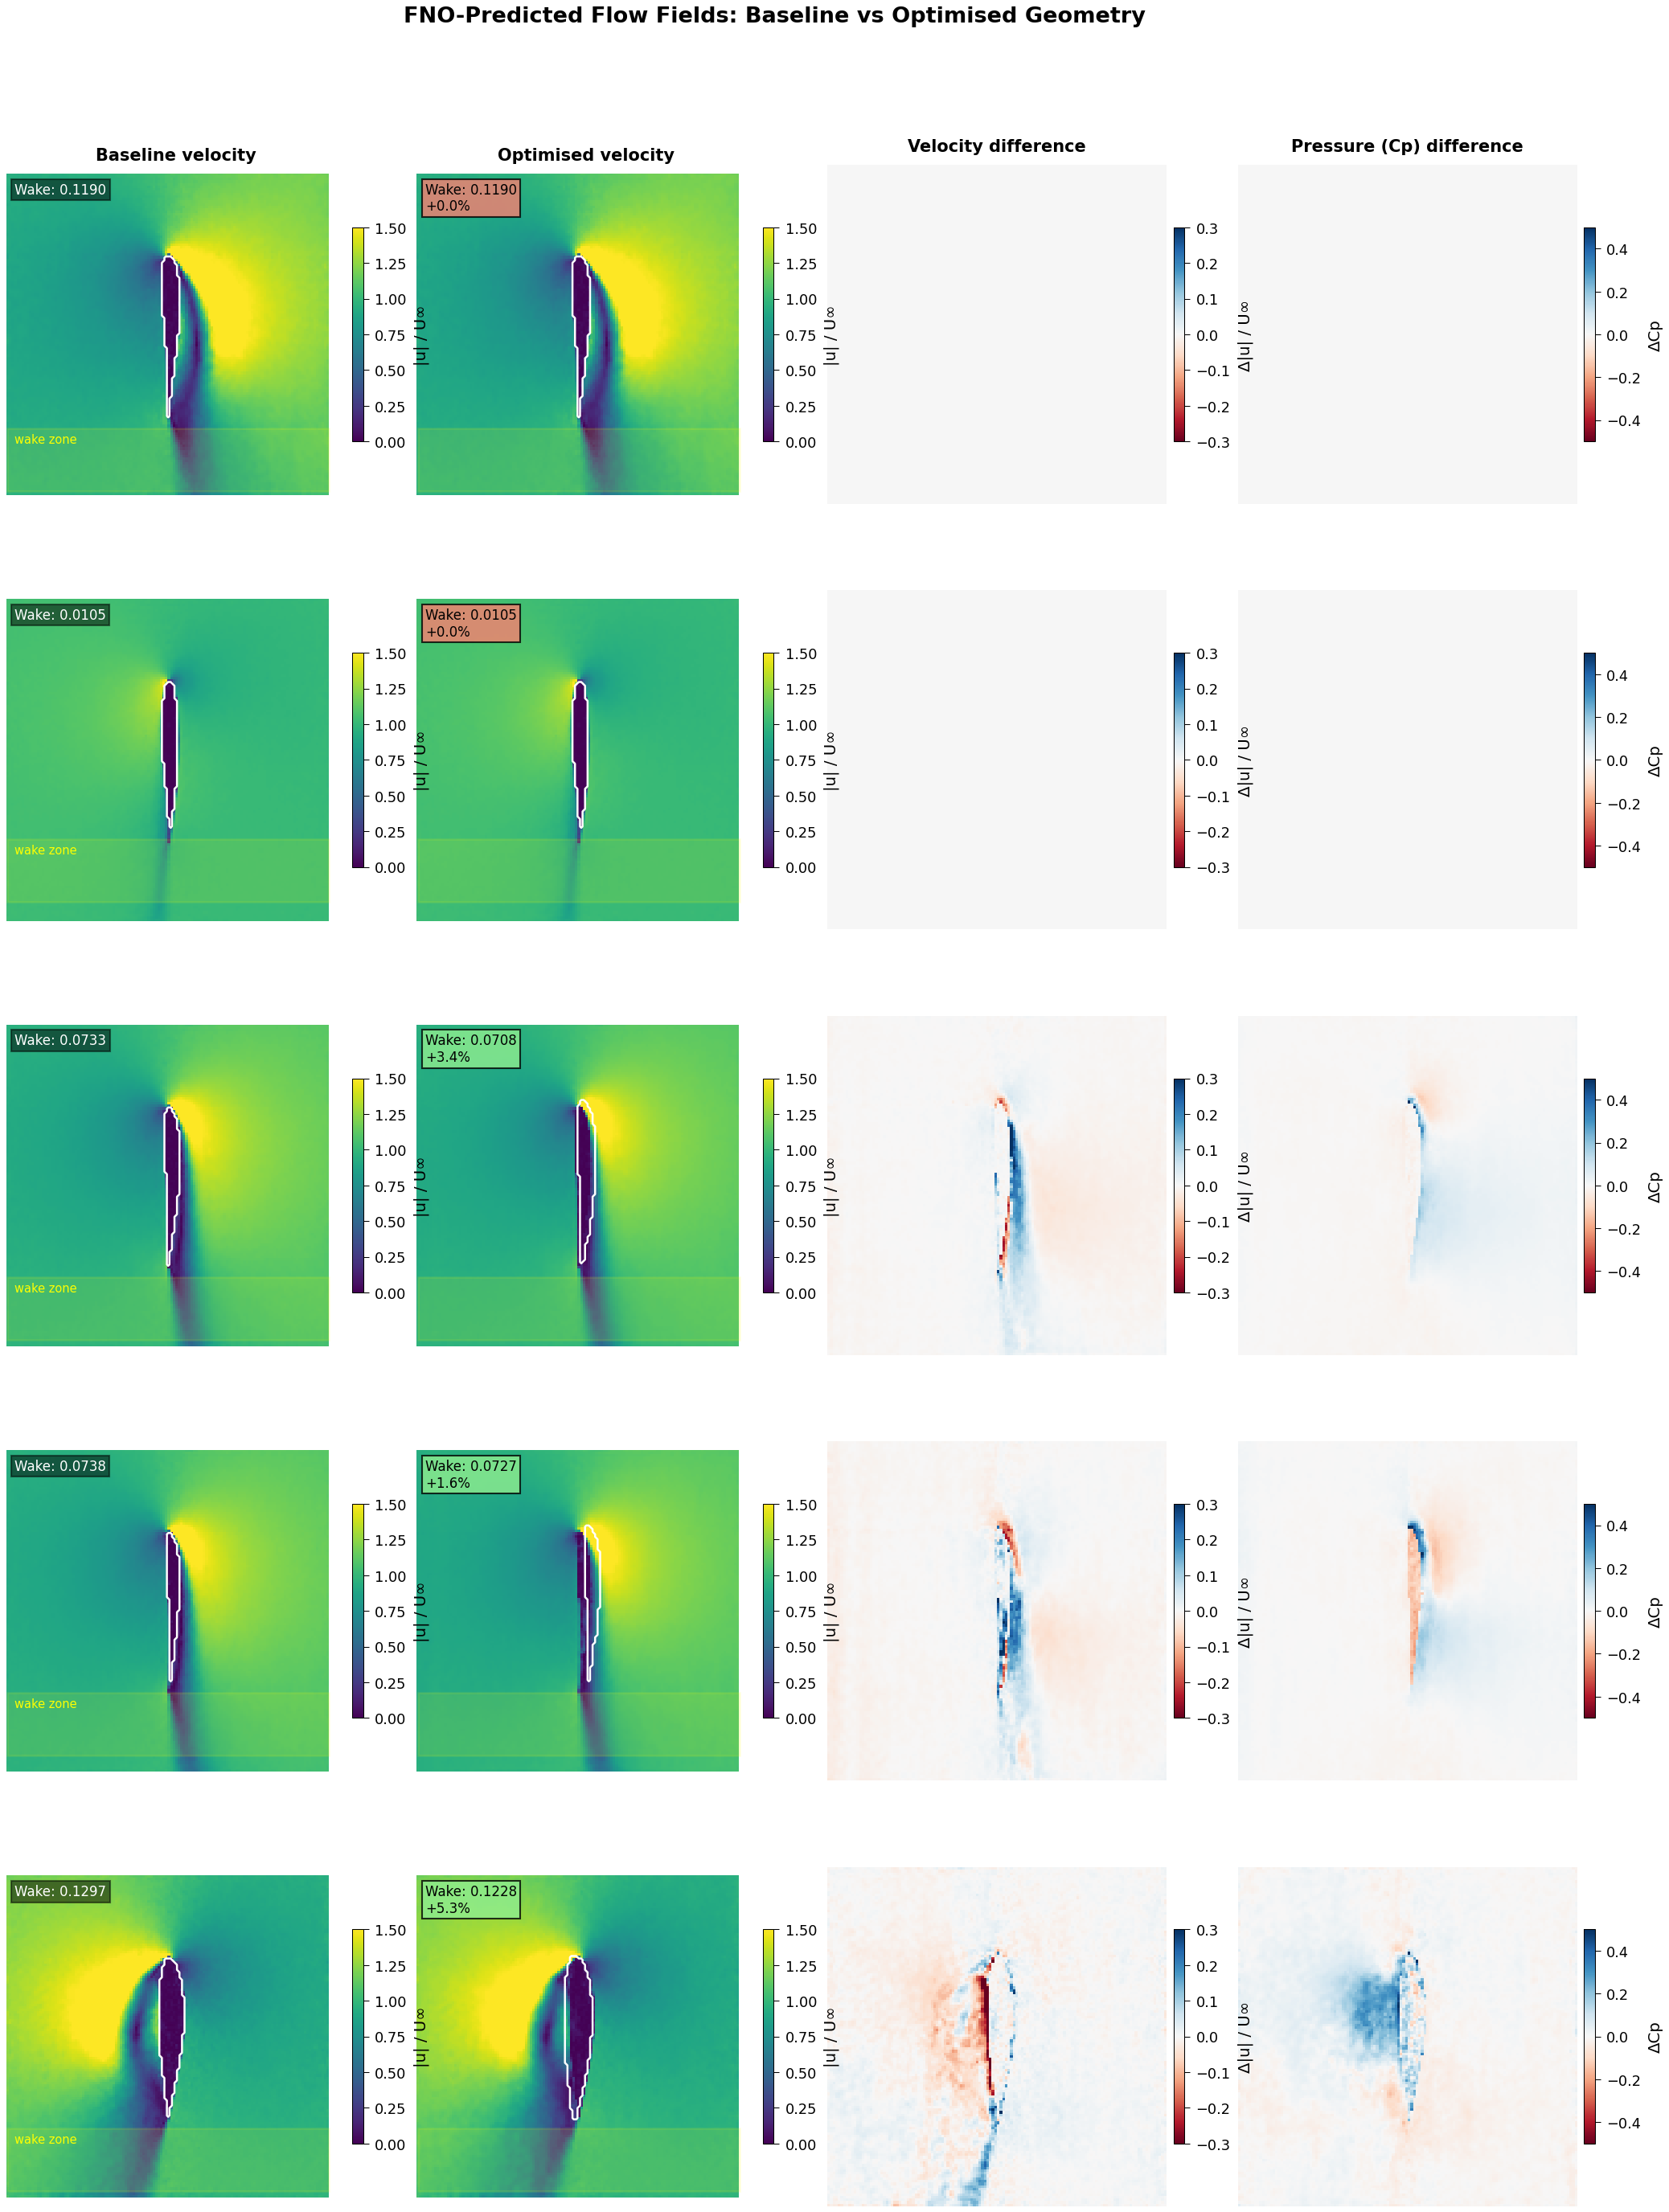

Saved: inverse_design/flow_comparison.png


In [20]:
import matplotlib.patches as patches

n_show = min(5, len(results))
fig, axes = plt.subplots(n_show, 4, figsize=(17, 4.5*n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('FNO-Predicted Flow Fields: Baseline vs Optimised Geometry',
             fontsize=13, fontweight='bold', y=0.93)

col_titles = ['Baseline velocity', 'Optimised velocity',
              'Velocity difference', 'Pressure (Cp) difference']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, pad=8)

for i in range(n_show):
    res   = results[i]
    idx   = res['idx']

    x, _ = val_ds[idx]
    x_init = x.unsqueeze(0).to(device)
    geom_opt = torch.tensor(res['final_geom'],
                             device=device, dtype=torch.float32)
    x_opt = torch.cat([x_init[:, :2],
                        geom_opt.unsqueeze(0).unsqueeze(0)], dim=1)

    with torch.no_grad():
        y_init = model(x_init)
        y_opt  = model(x_opt)

    u_init  = y_init[0, 1].cpu().numpy()
    v_init  = y_init[0, 2].cpu().numpy()
    vmag_i  = np.sqrt(u_init**2 + v_init**2)

    u_opt   = y_opt[0, 1].cpu().numpy()
    v_opt   = y_opt[0, 2].cpu().numpy()
    vmag_o  = np.sqrt(u_opt**2 + v_opt**2)

    init_crisp = (res['init_geom'] > 0.5)
    opt_crisp  = (res['final_geom'] > 0.5)

    # Find wake region for annotation
    g_t = torch.tensor(res['init_geom']).to(device)
    solid_rows = torch.any(g_t > 0.5, dim=1)
    if solid_rows.any():
        airfoil_bottom = torch.where(solid_rows)[0][-1].item()
        w_start = min(airfoil_bottom + 5,  127)
        w_end   = min(airfoil_bottom + 30, 128)
    else:
        w_start, w_end = 60, 90

    # Row label
    axes[i, 0].set_ylabel(
        f'Sample {idx}\nAoA={res["aoa"]:.1f}°',
        fontsize=9, labelpad=6
    )

    # Column 0: baseline velocity
    im0 = axes[i, 0].imshow(vmag_i, cmap='viridis', vmin=0, vmax=1.5)
    axes[i, 0].contour(init_crisp, colors='white', linewidths=1.2)
    rect0 = patches.Rectangle(
        (0, w_start), 128, w_end - w_start,
        linewidth=1.2, edgecolor='yellow',
        facecolor='yellow', alpha=0.12
    )
    axes[i, 0].add_patch(rect0)
    axes[i, 0].text(3, w_start + 2, 'wake zone',
                    color='yellow', fontsize=7, va='top')
    axes[i, 0].text(3, 3,
        f'Wake: {res["init_wake_def"]:.4f}',
        color='white', fontsize=8, va='top',
        bbox=dict(facecolor='black', alpha=0.5, pad=2))
    axes[i, 0].axis('off')
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.03,
                 pad=0.02, label='|u| / U∞')

    # Column 1: optimised velocity
    im1 = axes[i, 1].imshow(vmag_o, cmap='viridis', vmin=0, vmax=1.5)
    axes[i, 1].contour(opt_crisp, colors='white', linewidths=1.2)
    rect1 = patches.Rectangle(
        (0, w_start), 128, w_end - w_start,
        linewidth=1.2, edgecolor='yellow',
        facecolor='yellow', alpha=0.12
    )
    axes[i, 1].add_patch(rect1)
    imp_color = 'lightgreen' if res['improvement'] > 0 else 'salmon'
    axes[i, 1].text(3, 3,
        f'Wake: {res["final_wake_def"]:.4f}\n{res["improvement"]:+.1f}%',
        color='black', fontsize=8, va='top',
        bbox=dict(facecolor=imp_color, alpha=0.8, pad=2))
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.03,
                 pad=0.02, label='|u| / U∞')

    # Column 2: velocity difference
    vmag_diff = vmag_o - vmag_i
    im2 = axes[i, 2].imshow(vmag_diff, cmap='RdBu',
                              vmin=-0.3, vmax=0.3)
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.03,
                 pad=0.02, label='Δ|u| / U∞')

    # Column 3: Cp difference
    p_diff = y_opt[0, 0].cpu().numpy() - y_init[0, 0].cpu().numpy()
    im3 = axes[i, 3].imshow(p_diff, cmap='RdBu',
                              vmin=-0.5, vmax=0.5)
    axes[i, 3].axis('off')
    plt.colorbar(im3, ax=axes[i, 3], fraction=0.03,
                 pad=0.02, label='ΔCp')

plt.subplots_adjust(hspace=0.10, wspace=0.15)
plt.savefig(f'{OUTPUT_DIR}/flow_comparison.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/flow_comparison.png")

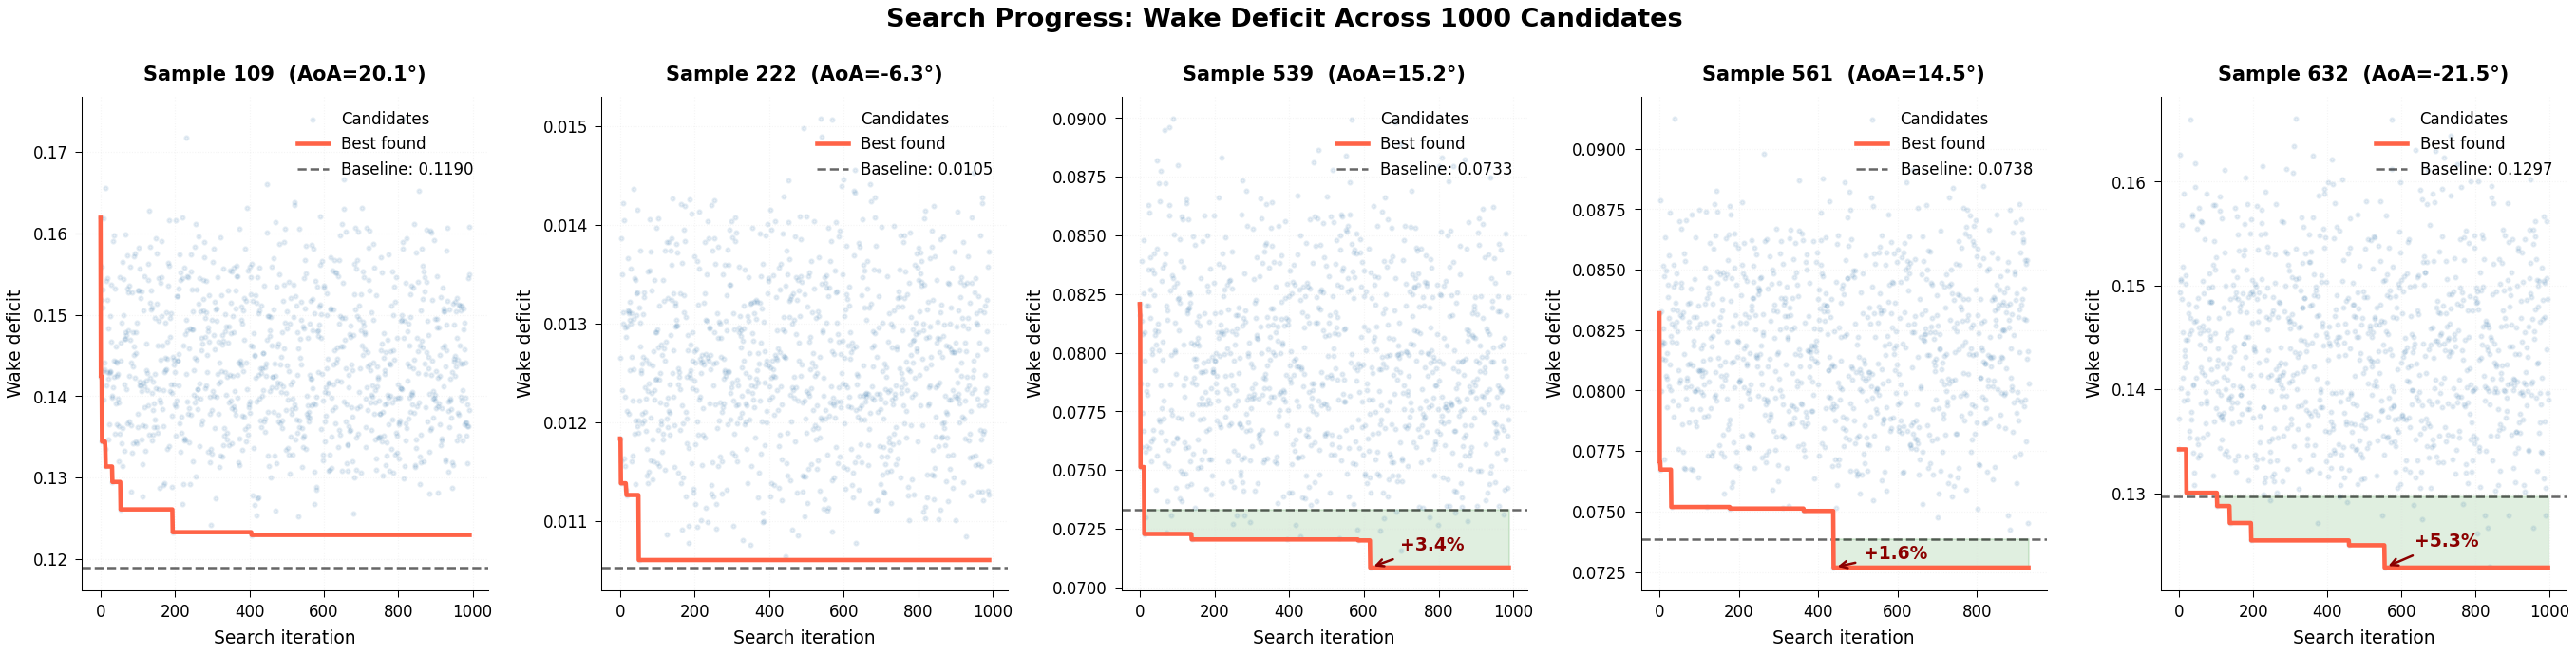

Saved: inverse_design/optimization_progress.png


In [12]:
n_show = min(5, len(results))
fig, axes = plt.subplots(1, n_show, figsize=(4.5*n_show, 4.5))
if n_show == 1:
    axes = [axes]

fig.suptitle('Search Progress: Wake Deficit Across 1000 Candidates',
             fontsize=13, fontweight='bold', y=1.02)

for i in range(n_show):
    res         = results[i]
    history     = res['history']
    running_min = np.minimum.accumulate(history)
    ax          = axes[i]

    # All candidates as faint scatter
    ax.scatter(range(len(history)), history,
               c='steelblue', alpha=0.12, s=4, label='Candidates', zorder=1)

    # Best-so-far line
    ax.plot(running_min, 'tomato', linewidth=2.2,
            label='Best found', zorder=3)

    # Baseline
    ax.axhline(y=res['init_wake_def'], color='black',
               linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'Baseline: {res["init_wake_def"]:.4f}', zorder=2)

    # Shade improvement region
    ax.fill_between(range(len(running_min)),
                    running_min, res['init_wake_def'],
                    where=[v < res['init_wake_def'] for v in running_min],
                    alpha=0.12, color='green', zorder=0)

    # Annotate best point
    if res['improvement'] > 0:
        best_iter = int(np.argmin(running_min))
        best_val  = running_min[best_iter]
        ax.annotate(
            f'{res["improvement"]:+.1f}%',
            xy=(best_iter, best_val),
            xytext=(best_iter + len(history)*0.08,
                    best_val + (res['init_wake_def'] - best_val)*0.3),
            fontsize=9, color='darkred', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2)
        )

    ax.set_xlabel('Search iteration', fontsize=9)
    ax.set_ylabel('Wake deficit', fontsize=9)
    ax.set_title(f'Sample {res["idx"]}  (AoA={res["aoa"]:.1f}°)',
                 fontsize=10)
    ax.legend(fontsize=8, loc='upper right',
              framealpha=0.85, edgecolor='lightgray')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=8)

plt.subplots_adjust(wspace=0.28)
plt.savefig(f'{OUTPUT_DIR}/optimization_progress.png', dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/optimization_progress.png")

/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 128]. This behavior is deprecated, and in a future PyTorch release outputs w

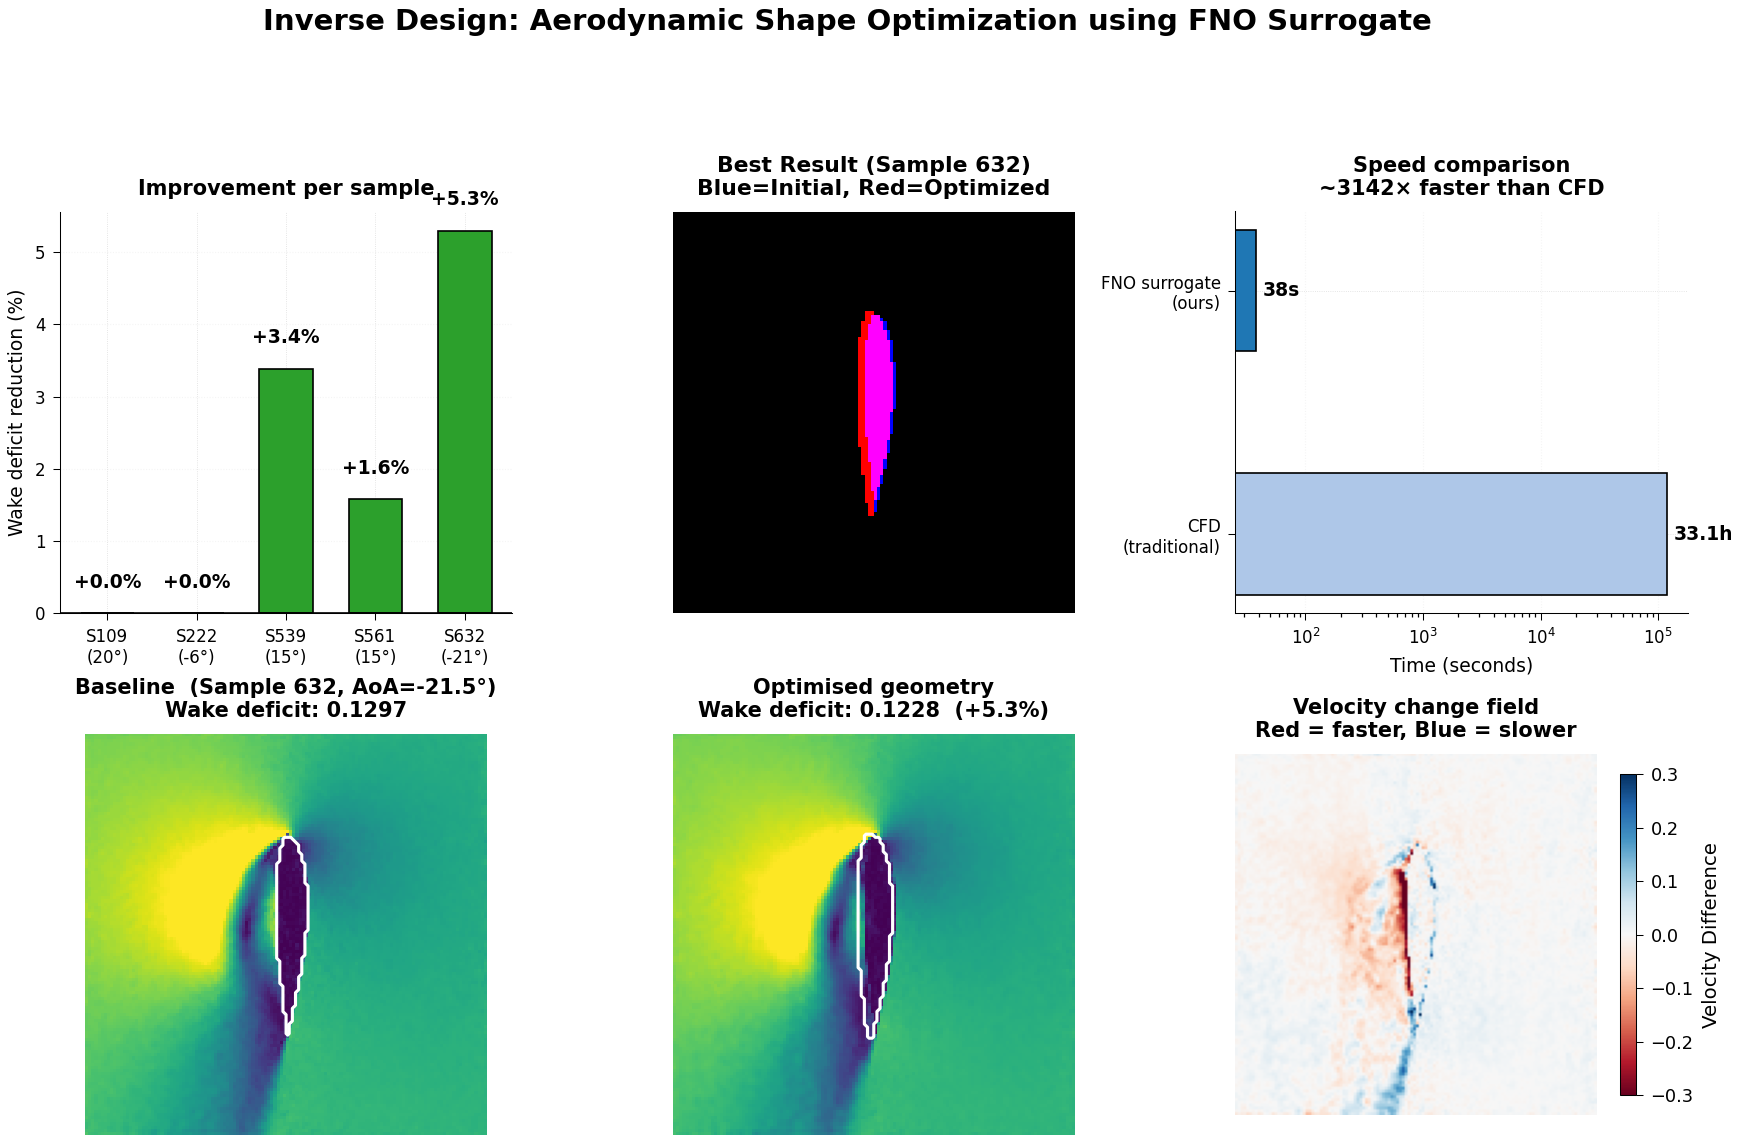


Saved: inverse_design/paper_summary_figure.png

Stage 4 Complete: Inverse design demonstrated successfully!


In [13]:
# 
# 11. Summary Figure for Paper
# 

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Find best result for showcase
best_idx = np.argmax([r['improvement'] for r in results])
best_res = results[best_idx]


ax1 = fig.add_subplot(gs[0, 0])
samples      = [r['idx'] for r in results]
improvements = [r['improvement'] for r in results]
aoas         = [r['aoa'] for r in results]

colors = ['#2ca02c' if imp > 0 else '#d62728' for imp in improvements]
bars = ax1.bar(range(len(samples)), improvements,
               color=colors, edgecolor='black',
               linewidth=0.8, width=0.6)

# Value labels on bars
for bar, imp in zip(bars, improvements):
    yoff = 0.3 if imp >= 0 else -0.8
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + yoff,
             f'{imp:+.1f}%',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_xticks(range(len(samples)))
ax1.set_xticklabels(
    [f'S{s}\n({a:.0f}°)' for s, a in zip(samples, aoas)],
    fontsize=8
)
ax1.set_ylabel('Wake deficit reduction (%)', fontsize=9)
ax1.set_title('Improvement per sample', fontsize=10)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='y', linewidth=0.5)
ax1.tick_params(labelsize=8)

# Top middle: Best case geometry comparison
ax2 = fig.add_subplot(gs[0, 1])
overlay = np.zeros((*best_res['init_geom'].shape, 3))
overlay[..., 2] = (best_res['init_geom'] > 0.5)  # Blue = initial
overlay[..., 0] = (best_res['final_geom'] > 0.5)  # Red = optimized
ax2.imshow(overlay)
ax2.set_title(f'Best Result (Sample {best_res["idx"]})\nBlue=Initial, Red=Optimized')
ax2.axis('off')


ax3 = fig.add_subplot(gs[0, 2])
cfd_time = results[0]['valid_samples'] * 120
fno_time = np.mean([r['time'] for r in results])
speedup  = cfd_time / fno_time

ax3.barh(['CFD\n(traditional)', 'FNO surrogate\n(ours)'],
         [cfd_time, fno_time],
         color=['#aec7e8', '#1f77b4'],
         edgecolor='black', linewidth=0.8, height=0.5)
ax3.set_xscale('log')
ax3.set_xlabel('Time (seconds)', fontsize=9)
ax3.set_title(f'Speed comparison\n~{speedup:.0f}× faster than CFD', fontsize=10)

for y, t in enumerate([cfd_time, fno_time]):
    label = (f'{t/3600:.1f}h' if t > 3600
             else f'{t/60:.0f} min' if t > 60
             else f'{t:.0f}s')
    ax3.text(t * 1.15, y, label,
             va='center', fontsize=9, fontweight='bold')

ax3.tick_params(labelsize=8)
ax3.grid(True, alpha=0.3, axis='x', linewidth=0.5)

# Bottom: Best case flow comparison
x, _ = val_ds[best_res['idx']]
x_init = x.unsqueeze(0).to(device)
geom_opt = torch.tensor(best_res['final_geom'], device=device, dtype=torch.float32)
x_opt = torch.cat([x_init[:, :2], geom_opt.unsqueeze(0).unsqueeze(0)], dim=1)

with torch.no_grad():
    y_init = model(x_init)
    y_opt = model(x_opt)

u_init = y_init[0, 1].cpu().numpy()
v_init = y_init[0, 2].cpu().numpy()
vmag_init = np.sqrt(u_init**2 + v_init**2)

u_opt = y_opt[0, 1].cpu().numpy()
v_opt = y_opt[0, 2].cpu().numpy()
vmag_opt = np.sqrt(u_opt**2 + v_opt**2)

ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(vmag_init, cmap='viridis', vmin=0, vmax=1.5)
ax4.contour(best_res['init_geom'] > 0.5, colors='white', linewidths=1.5)
ax4.set_title(
    f'Baseline  (Sample {best_res["idx"]}, AoA={best_res["aoa"]:.1f}°)\n'
    f'Wake deficit: {best_res["init_wake_def"]:.4f}',
    fontsize=10
)
# ax4.set_title(f'Initial Flow\nWake deficit: {best_res["init_wake_def"]:.4f}')
ax4.axis('off')

ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(vmag_opt, cmap='viridis', vmin=0, vmax=1.5)
ax5.contour(best_res['final_geom'] > 0.5, colors='white', linewidths=1.5)
ax5.set_title(
    f'Optimised geometry\n'
    f'Wake deficit: {best_res["final_wake_def"]:.4f}  '
    f'({best_res["improvement"]:+.1f}%)',
    fontsize=10
)
# ax5.set_title(f'Optimized Flow\nWake deficit: {best_res["final_wake_def"]:.4f}')
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 2])

vmag_diff = vmag_opt - vmag_init
im = ax6.imshow(vmag_diff, cmap='RdBu', vmin=-0.3, vmax=0.3)

ax6.set_title(
    f'Velocity change field\n'
    f'Red = faster, Blue = slower',
    fontsize=10
)

# ax6.set_title(f'Velocity Change\n{best_res["improvement"]:+.1f}% wake deficit reduction')
ax6.axis('off')

plt.colorbar(im, ax=ax6, shrink=0.8, label='Velocity Difference')

fig.suptitle(
    'Inverse Design: Aerodynamic Shape Optimization using FNO Surrogate',
    fontsize=14,
    fontweight='bold',
    y=1.05
)

plt.savefig(f'{OUTPUT_DIR}/paper_summary_figure.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR}/paper_summary_figure.png")
print("\n" + "=" * 70)
print("Stage 4 Complete: Inverse design demonstrated successfully!")
print("=" * 70)